# MetroPT2: operating cycles and sensor relationships

Explore real compressor signals alongside binary controls. Unlike GDD, MetroPT2
has no per-sample operating-state labels. Control combinations below are
**descriptive reference codes**, not ground-truth states or fault classes.

[Official source](https://zenodo.org/records/7766691)
· [Dataset guide](../../pdmdata/metropt2/README.md)

Run `pdmdata.download("metropt2")` explicitly if local data is missing. This
notebook reads a limited prefix of the downloaded CSV, without downloading or
saving another copy of the raw measurements.


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pdmdata").is_dir())
sys.path.insert(0,str(ROOT))
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display
import pdmdata
from pdmdata.metropt2.viz import ANALOG_SIGNALS, CONTROL_SIGNALS, plot_operation

scan = pdmdata.load("metropt2")
print("Source columns:", scan.collect_schema().names())
N_SAMPLES = 21600
sample = scan.select(["timestamp", *ANALOG_SIGNALS, *CONTROL_SIGNALS]).head(N_SAMPLES).collect()
print(f"Loaded {sample.height:,} observations; {sample['timestamp'][0]} to {sample['timestamp'][-1]}")
display(sample.head())


Source columns: ['timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Flowmeter', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses', 'gpsLat', 'gpsLong', 'gpsSpeed', 'gpsQuality']
Loaded 21,600 observations; 2022-04-28 12:33:29.120000 to 2022-04-28 18:30:18.723000


timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Flowmeter,Motor_current,COMP,DV_eletric,Towers
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2022-04-28 12:33:29.120,-0.014,8.06,1.136,-0.02,8.066,57.125,0.25,4.91,0.0,1.0,0.0
2022-04-28 12:33:30.111,0.156,8.058,-0.02,-0.018,8.066,57.2,0.25,4.7325,0.0,1.0,0.0
2022-04-28 12:33:31.102,1.094,8.058,-0.026,-0.018,8.066,57.15,0.25,4.91,0.0,1.0,0.0
2022-04-28 12:33:32.093,2.482,8.058,-0.026,-0.018,8.064,57.125,0.25,4.82,0.0,1.0,0.0
2022-04-28 12:33:33.084,3.756,8.058,-0.024,-0.018,8.066,57.075,0.25,4.91,0.0,1.0,0.0


## Sampling and signal checks

The provider describes nominal 1 Hz logging; actual timestamps can be irregular.
We retain observed timestamps and do not resample. The plotted prefix is an
illustration, not a representative sample of all operating and fault conditions.


In [2]:
dt = sample["timestamp"].diff().dt.total_milliseconds()/1000
print(f"Median interval: {dt.median():.3f} s; minimum: {dt.min():.3f}; maximum: {dt.max():.3f}")
print(f"Backward steps: {(dt < 0).sum()}; duplicate steps: {(dt == 0).sum()}; gaps > 5 s: {(dt > 5).sum()}")
display(sample.null_count())
display(pl.DataFrame({
    "signal": ANALOG_SIGNALS,
    "unique_values": [sample[c].n_unique() for c in ANALOG_SIGNALS],
    "standard_deviation": [sample[c].std() for c in ANALOG_SIGNALS],
}))
print("Constant analogue channels in this window:",
      [c for c in ANALOG_SIGNALS if sample[c].drop_nulls().n_unique() <= 1])
for c in CONTROL_SIGNALS:
    print(c, "observed values:", sample[c].unique().sort().to_list())
assert sample["timestamp"].is_sorted(), "Inspect timestamp reversals before plotting"


Median interval: 0.991 s; minimum: 0.009; maximum: 1.981
Backward steps: 0; duplicate steps: 0; gaps > 5 s: 0


timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Flowmeter,Motor_current,COMP,DV_eletric,Towers
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0


signal,unique_values,standard_deviation
str,i64,f64
"""TP2""",1190,2.813738
"""TP3""",1113,0.56402
"""H1""",1087,2.78661
"""DV_pressure""",51,0.132426
"""Reservoirs""",1110,0.563303
"""Oil_temperature""",483,2.848998
"""Flowmeter""",1,0.0
"""Motor_current""",572,2.200442


Constant analogue channels in this window: ['Flowmeter']
COMP observed values: [0.0, 1.0]
DV_eletric observed values: [0.0, 1.0]
Towers observed values: [0.0, 1.0]


## Overview: repeated control changes and sensor response

The upper panel shows each binary control separately, vertically offset for
readability. Analogue signals retain their source values. Gaps longer than five
seconds are broken in the traces; no smoothing or interpolation is applied.


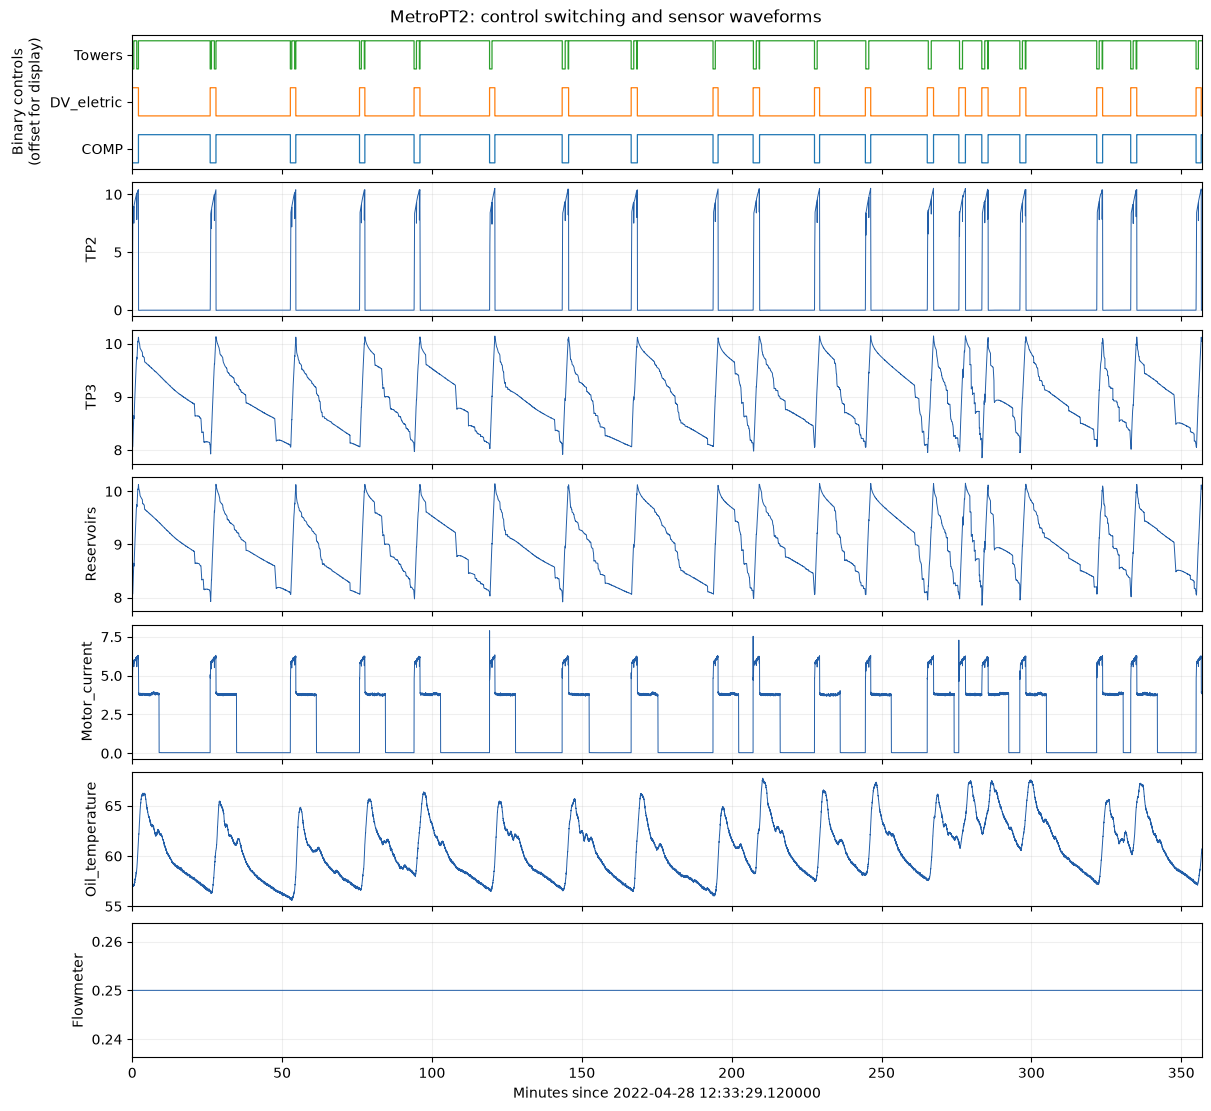

In [3]:
overview = plot_operation(sample)
plt.show()


## Zoom into a 20-minute interval

Adjust START_MINUTES and WINDOW_MINUTES to inspect another part of the prefix.
The default starts at the beginning, without selecting for a particular fault.


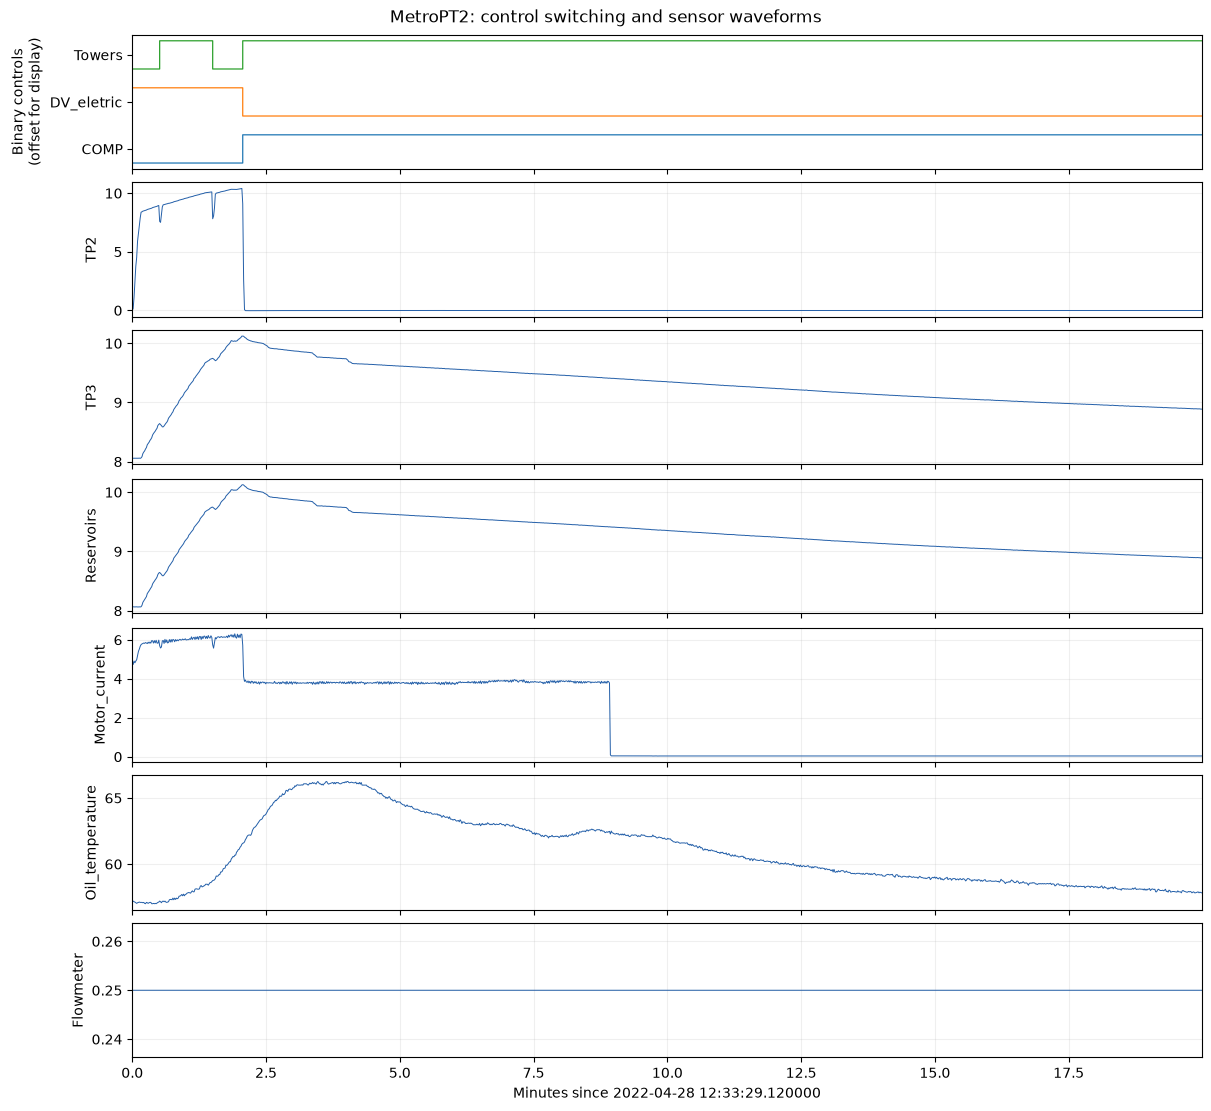

In [4]:
START_MINUTES, WINDOW_MINUTES = 0, 20
elapsed = (pl.col("timestamp") - sample["timestamp"][0]).dt.total_milliseconds()/60000
window = sample.filter((elapsed >= START_MINUTES) & (elapsed < START_MINUTES + WINDOW_MINUTES))
zoom = plot_operation(window)
plt.show()


## Observed control combinations and their persistence

Encode `COMP + 2 * DV_eletric + 4 * Towers` only to identify combinations.
The numeric order does not mean severity, and the eight possible codes need not
all occur. Control signals can lag or lead the analogue response. Keep them out
of sensor-only model inputs if using them as evaluation references.


In [5]:
for c in CONTROL_SIGNALS:
    assert sample[c].null_count() == 0 and set(sample[c].unique().to_list()) <= {0,1}
annotated = sample.with_row_index("sample_index").with_columns(
    (pl.col("COMP") + 2*pl.col("DV_eletric") + 4*pl.col("Towers")).cast(pl.UInt8).alias("control_code")
)
# Do not count transitions or segment lengths across recording gaps.
breaks = ((pl.col("control_code") != pl.col("control_code").shift(1)) |
          (pl.col("timestamp").diff().dt.total_milliseconds() > 5000)).fill_null(True)
segments = annotated.with_columns(breaks.cast(pl.UInt32).cum_sum().alias("segment"))
segments = segments.group_by("segment", maintain_order=True).agg(
    pl.col("control_code").first(), pl.col("timestamp").first().alias("start"),
    pl.col("timestamp").last().alias("last_observation"), pl.len().alias("samples")
).with_columns((pl.col("last_observation")-pl.col("start")).dt.total_milliseconds().truediv(1000).alias("observed_span_s"))
display(annotated.group_by(CONTROL_SIGNALS + ["control_code"]).len().sort("control_code"))
display(segments.group_by("control_code").agg(pl.len().alias("segments"),
    pl.col("samples").median().alias("median_samples"),
    pl.col("observed_span_s").median().alias("median_observed_span_s")).sort("control_code"))
display(segments.head(12))


COMP,DV_eletric,Towers,control_code,len
f64,f64,f64,u8,u32
0.0,1.0,0.0,2,1106
1.0,0.0,1.0,5,19362
0.0,1.0,1.0,6,1132


control_code,segments,median_samples,median_observed_span_s
u8,u32,f64,f64
2,31,37.0,35.674
5,19,1142.0,1131.033
6,24,59.0,57.474


segment,control_code,start,last_observation,samples,observed_span_s
u32,u8,datetime[μs],datetime[μs],u32,f64
1,2,2022-04-28 12:33:29.120,2022-04-28 12:33:58.847,31,29.727
2,6,2022-04-28 12:33:59.838,2022-04-28 12:34:58.303,60,58.465
3,2,2022-04-28 12:34:59.294,2022-04-28 12:35:31.994,34,32.7
4,5,2022-04-28 12:35:32.985,2022-04-28 12:59:27.958,1449,1434.973
5,2,2022-04-28 12:59:28.949,2022-04-28 12:59:52.736,25,23.787
…,…,…,…,…,…
8,5,2022-04-28 13:01:24.907,2022-04-28 13:26:13.319,1503,1488.412
9,2,2022-04-28 13:26:14.310,2022-04-28 13:26:41.066,28,26.756
10,6,2022-04-28 13:26:42.057,2022-04-28 13:27:39.533,59,57.476


## Analogue profiles for each observed control combination

These descriptive medians help identify how pressure, current, temperature,
and flow vary with control signals. They are not learned dependency graphs.


In [6]:
display(annotated.group_by("control_code").agg(pl.col(ANALOG_SIGNALS).median()).sort("control_code"))


control_code,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Flowmeter,Motor_current
u8,f64,f64,f64,f64,f64,f64,f64,f64
2,8.87,8.584,-0.018,-0.018,8.58,58.1125,0.25,5.87
5,-0.012,8.95,8.934,-0.018,8.952,60.5,0.25,0.04
6,9.865,9.482,-0.012,-0.018,9.48,59.3375,0.25,6.07625


## Fault reports are a separate source of information

The source CSV is unlabeled. The provider lists these intervals:

| Report | Start | End |
|---|---|---|
| Air leak | 2022-06-04 10:19:24.300 | 2022-06-04 14:22:39.188 |
| Oil leak | 2022-07-11 10:10:18.948 | 2022-07-14 10:22:08.046 |

The default prefix predates both intervals. Neither absence from these intervals
nor a particular control code establishes healthy operation. To inspect another
period, filter the lazy scan by timestamp before collecting a limited window.

## Relevance to dependency-based segmentation

- Start with the eight analogue signals; GPS and binary controls are excluded.
- Examine constant channels and scale differences within each training block.
- Distinguish changes in mean/variance from changes in conditional dependencies.
- Compare sensor-only segmentation with the observed control switching, while
  recognizing that these controls are not independent ground-truth annotations.
- Evaluate multiple separated periods; this short prefix alone cannot establish
  multi-scale behavior or generalization across the whole recording.
